<a href="https://colab.research.google.com/github/mnsbharadwaj/AI-NLP/blob/master/transformer_based_llm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import numpy as np
import requests
from tqdm import tqdm

# 1. Download and load the Tiny Shakespeare dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text

# 2. Preprocess the dataset
chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}
data = [char_to_idx[ch] for ch in text]

# 3. Create input-output pairs for training
seq_length = 25
X, y = [], []
for i in range(0, len(data) - seq_length):
    X.append(data[i:i + seq_length])
    y.append(data[i + 1:i + seq_length + 1])
X = torch.tensor(X, dtype=torch.long)
y = torch.tensor(y, dtype=torch.long)

# 4. Define Multi-Head Attention
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, num_heads):
        super().__init__()
        assert embed_size % num_heads == 0, "Embedding size must be divisible by number of heads"
        self.embed_size = embed_size
        self.num_heads = num_heads
        self.head_dim = embed_size // num_heads

        self.query = nn.Linear(embed_size, embed_size)
        self.key = nn.Linear(embed_size, embed_size)
        self.value = nn.Linear(embed_size, embed_size)
        self.fc_out = nn.Linear(embed_size, embed_size)

        self.scale = torch.sqrt(torch.tensor(self.head_dim, dtype=torch.float32))

    def forward(self, x, mask=None):
        batch_size = x.shape[0]

        Q = self.query(x).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.key(x).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.value(x).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = torch.softmax(scores, dim=-1)
        out = torch.matmul(attn, V)

        out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.embed_size)
        out = self.fc_out(out)
        return out

# 5. Define the Transformer-based Tiny LLM
class TinyLLM(nn.Module):
    def __init__(self, vocab_size, embed_size, num_heads, num_layers):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.pos_embedding = nn.Embedding(seq_length, embed_size)
        self.layers = nn.ModuleList([
            nn.ModuleList([
                MultiHeadAttention(embed_size, num_heads),
                nn.LayerNorm(embed_size),
                nn.Linear(embed_size, embed_size * 4),
                nn.ReLU(),
                nn.Linear(embed_size * 4, embed_size),
                nn.LayerNorm(embed_size)
            ]) for _ in range(num_layers)
        ])
        self.fc = nn.Linear(embed_size, vocab_size)

    def forward(self, x):
        batch_size = x.shape[0]
        positions = torch.arange(0, x.size(1), device=x.device).unsqueeze(0).expand(batch_size, -1)

        x = self.embedding(x) + self.pos_embedding(positions)

        for attn, norm1, ff1, relu, ff2, norm2 in self.layers:
            x = norm1(x + attn(x))
            x = norm2(x + ff2(relu(ff1(x))))

        out = self.fc(x)
        return out

# 6. Model parameters and setup
embed_size = 128
num_heads = 4
num_layers = 2
model = TinyLLM(vocab_size, embed_size, num_heads, num_layers)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 7. Training loop with progress bar
num_epochs = 2
batch_size = 64
model.train()
for epoch in range(num_epochs):
    # Initialize tqdm progress bar for the batch loop
    progress_bar = tqdm(range(0, X.size(0), batch_size), desc=f'Epoch {epoch+1}/{num_epochs}', leave=True)
    for i in progress_bar:
        inputs = X[i:i + batch_size]
        targets = y[i:i + batch_size]

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output.view(-1, vocab_size), targets.view(-1))
        loss.backward()
        optimizer.step()

        if i % 1000 == 0:
            progress_bar.set_postfix(loss=f'{loss.item():.4f}')

# 8. Generate text
def generate_text(model, seed_text, length=100):
    model.eval()
    input_seq = torch.tensor([char_to_idx[ch] for ch in seed_text], dtype=torch.long).unsqueeze(0)

    generated = seed_text
    for _ in range(length):
        output = model(input_seq)
        probs = torch.softmax(output[:, -1, :], dim=-1)
        next_char_idx = torch.multinomial(probs, num_samples=1).item()
        generated += idx_to_char[next_char_idx]
        input_seq = torch.tensor([char_to_idx[ch] for ch in generated[-seq_length:]], dtype=torch.long).unsqueeze(0)

    return generated

# 9. Generate sample output
seed = "To be or not to be"
generated_text = generate_text(model, seed, length=100)
print("\nGenerated Text:")
print(generated_text)

Epoch 2/2: 100%|██████████| 17428/17428 [20:43<00:00, 14.02it/s, loss=0.0682]



Generated Text:
To be or not to beSooottters;
Amell one all 'sis thou thing,--

ABOSSO:
I am a heavy; they was' visity so father piry



# **VIEW THE MODEL**

In [6]:
!pip install torchinfo
from torchinfo import summary
batch_size = 64

model = TinyLLM(vocab_size, embed_size, num_heads, num_layers)
summary(model, input_size=(batch_size, seq_length), dtypes=[torch.long]) # Changed block_size to seq_length

Layer (type:depth-idx)                   Output Shape              Param #
TinyLLM                                  [64, 25, 65]              --
├─Embedding: 1-1                         [64, 25, 128]             8,320
├─Embedding: 1-2                         [64, 25, 128]             3,200
├─ModuleList: 1-3                        --                        --
│    └─ModuleList: 2-1                   --                        --
│    │    └─MultiHeadAttention: 3-1      [64, 25, 128]             66,048
│    │    └─LayerNorm: 3-2               [64, 25, 128]             256
│    │    └─Linear: 3-3                  [64, 25, 512]             66,048
│    │    └─ReLU: 3-4                    [64, 25, 512]             --
│    │    └─Linear: 3-5                  [64, 25, 128]             65,664
│    │    └─LayerNorm: 3-6               [64, 25, 128]             256
│    └─ModuleList: 2-2                   --                        --
│    │    └─MultiHeadAttention: 3-7      [64, 25, 128]           

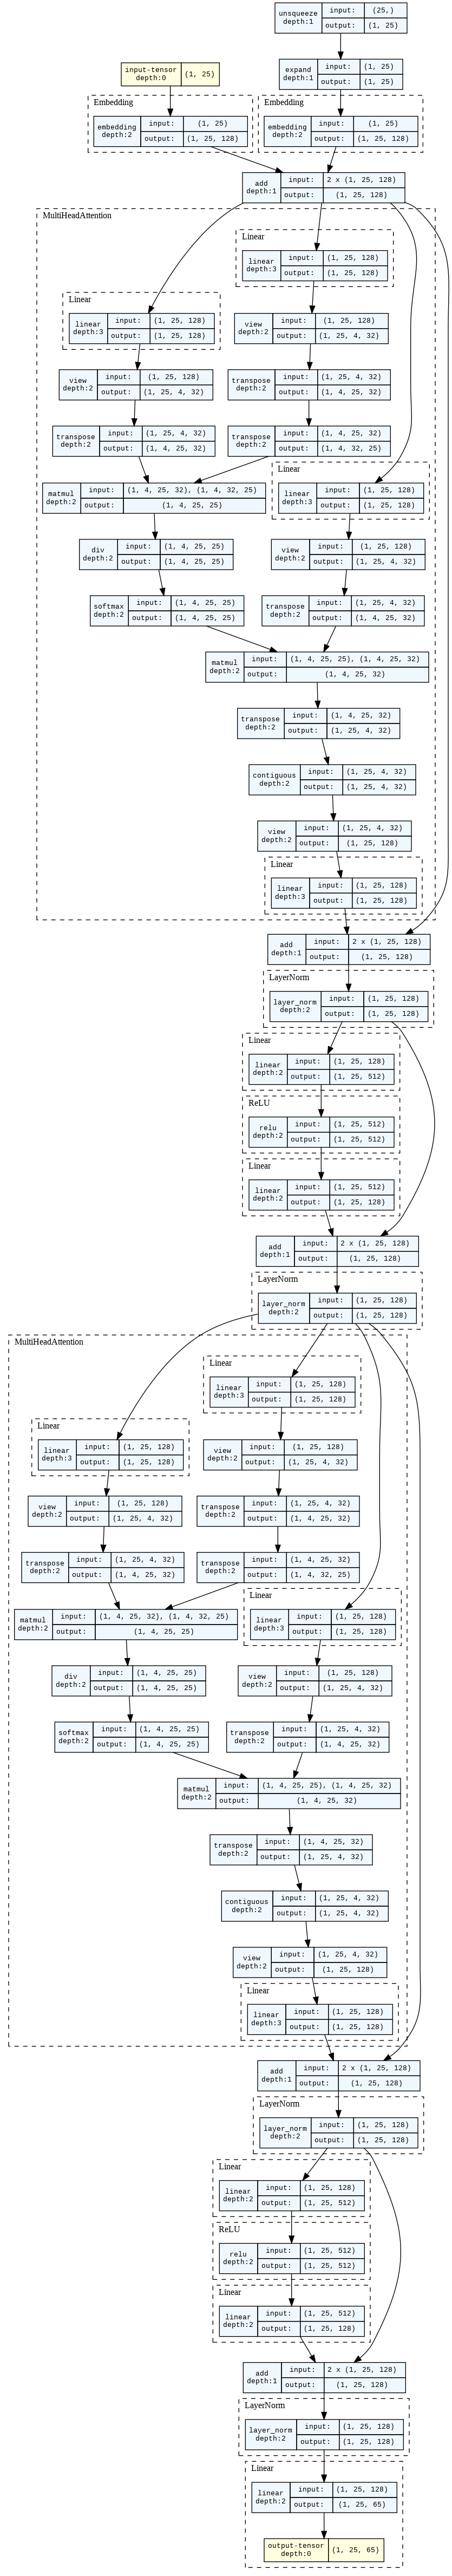

In [8]:
!pip install torchview  # For static visualization
!pip install tensorboard  # For interactive visualization
from torchview import draw_graph
from IPython.display import Image, display # Import Image and display from IPython.display

# Create sample input
input_example = torch.zeros((1, seq_length), dtype=torch.long).to('cpu') # Changed block_size to seq_length

# Generate graph visualization
model_graph = draw_graph(
    model,
    input_data=input_example,
    depth=10,               # How many layers to show
    expand_nested=True,     # Show details of nested modules
    hide_module_functions=False  # Show internal operations
)

# Save and display
model_graph.visual_graph.render(filename='model_architecture', format='png')
display(Image('model_architecture.png')) # Use Image class to display the file